# Desafio Extra - Hotel Booking Demand

**Autor:** Jonathan Euzébio Boza

**Objetivo:** analisar a base `hotel_bookings.csv`, entender os principais fatores ligados ao cancelamento de reservas e construir um modelo preditivo introdutório para a variável `is_canceled`.

A solução segue as etapas pedidas no enunciado: compreensão do conjunto, tratamento dos dados, análise exploratória, modelagem preditiva e avaliação final.

## 1. Observação

O problema usa um dataset real de reservas de hotéis com informações sobre estadia, antecedência da reserva, tipo de hotel, país de origem, tarifas e histórico do cliente.

A variável-alvo será `is_canceled`, indicando se a reserva foi cancelada (`1`) ou não (`0`).

In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 80)

## 2. Importação e compreensão dos dados

Nesta etapa vamos carregar o CSV, tratar valores ausentes codificados como `NULL`, remover duplicatas e criar algumas variáveis derivadas úteis para a análise.

In [21]:
data_path = Path(r'c:/Users/jebcode/Documents/SCTEC/Inteligência Artificial/hotel_bookings.csv')

df = pd.read_csv(
    data_path,
    na_values=['NULL', 'null', 'None', ''],
    parse_dates=['reservation_status_date'],
)

df.columns = df.columns.str.strip()
df = df.drop_duplicates().copy()

numeric_columns = [
    'is_canceled',
    'lead_time',
    'arrival_date_year',
    'arrival_date_week_number',
    'arrival_date_day_of_month',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'is_repeated_guest',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests',
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

df['children'] = df['children'].fillna(0)
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']

display(df.head())
print(f'Linhas: {df.shape[0]:,}')
print(f'Colunas: {df.shape[1]}')
print('Taxa de cancelamento:', round(df['is_canceled'].mean() * 100, 2), '%')

missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame('faltantes').head(15))

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,total_guests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,2,2.0


Linhas: 87,396
Colunas: 34
Taxa de cancelamento: 27.49 %


,faltantes
company,82137
agent,12193
country,452


## 3. Tratamento e preparação dos dados

Para a modelagem, removemos colunas que não ajudam a prever o cancelamento ou que podem vazar informação do resultado, como `reservation_status` e `reservation_status_date`.

Também evitamos variáveis com cardinalidade muito alta no modelo para manter a solução leve e estável.

## 4. Análise exploratória

Agora vamos observar padrões relevantes entre cancelamento, tipo de hotel, antecedência da reserva, tarifa média e tipo de depósito.

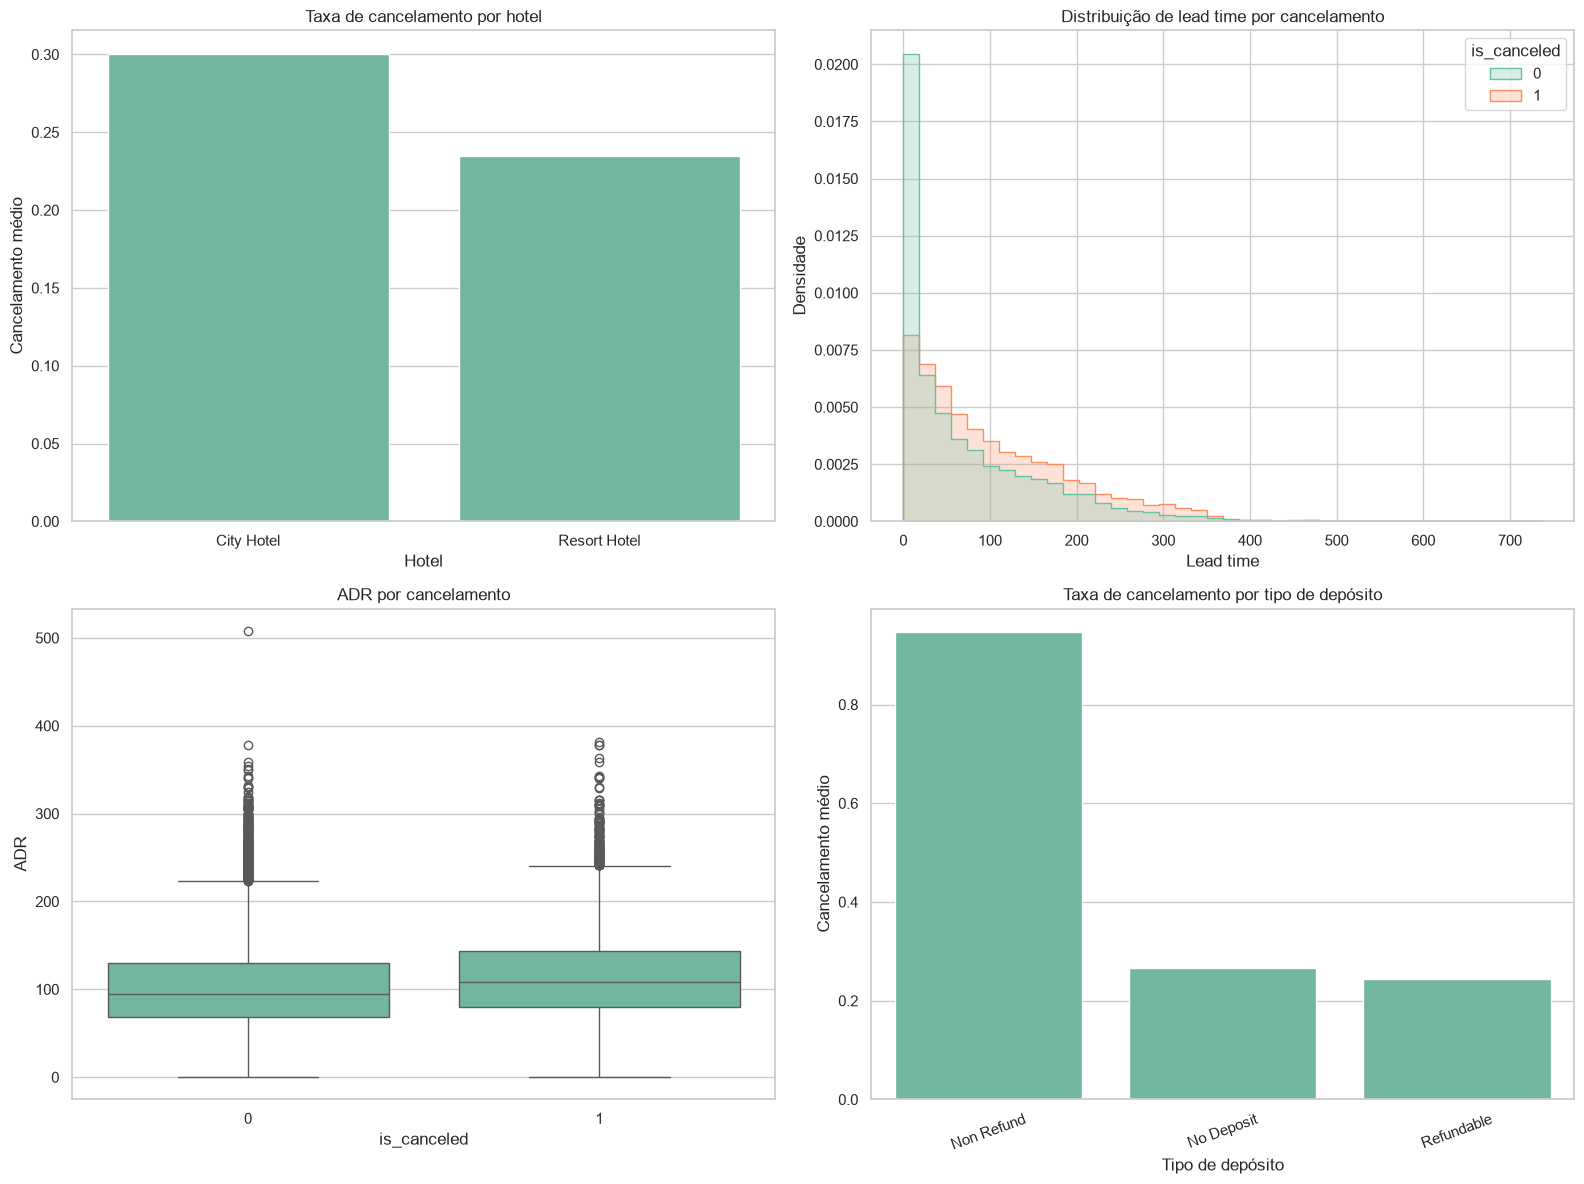

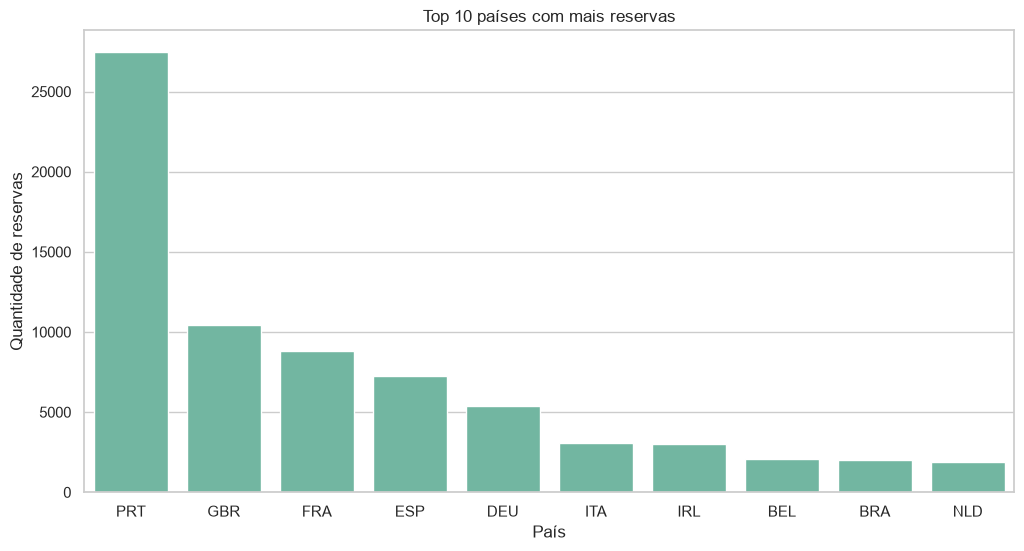

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

hotel_cancel = df.groupby('hotel', as_index=False)['is_canceled'].mean().sort_values('is_canceled', ascending=False)
sns.barplot(data=hotel_cancel, x='hotel', y='is_canceled', ax=axes[0, 0])
axes[0, 0].set_title('Taxa de cancelamento por hotel')
axes[0, 0].set_xlabel('Hotel')
axes[0, 0].set_ylabel('Cancelamento médio')

sns.histplot(data=df, x='lead_time', hue='is_canceled', bins=40, stat='density', common_norm=False, element='step', ax=axes[0, 1])
axes[0, 1].set_title('Distribuição de lead time por cancelamento')
axes[0, 1].set_xlabel('Lead time')
axes[0, 1].set_ylabel('Densidade')

sns.boxplot(data=df.sample(min(len(df), 20000), random_state=42), x='is_canceled', y='adr', ax=axes[1, 0])
axes[1, 0].set_title('ADR por cancelamento')
axes[1, 0].set_xlabel('is_canceled')
axes[1, 0].set_ylabel('ADR')

deposit_cancel = df.groupby('deposit_type', as_index=False)['is_canceled'].mean().sort_values('is_canceled', ascending=False)
sns.barplot(data=deposit_cancel, x='deposit_type', y='is_canceled', ax=axes[1, 1])
axes[1, 1].set_title('Taxa de cancelamento por tipo de depósito')
axes[1, 1].set_xlabel('Tipo de depósito')
axes[1, 1].set_ylabel('Cancelamento médio')
axes[1, 1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

top_countries = df['country'].value_counts().head(10).reset_index()
top_countries.columns = ['country', 'reservas']
plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries, x='country', y='reservas')
plt.title('Top 10 países com mais reservas')
plt.xlabel('País')
plt.ylabel('Quantidade de reservas')
plt.show()

## 5. Modelagem preditiva

Vamos criar um pipeline com imputação, codificação das variáveis categóricas e regressão logística balanceada. É um modelo simples, rápido e adequado para um primeiro experimento supervisionado.

In [23]:
feature_columns = [
    'hotel',
    'lead_time',
    'arrival_date_year',
    'arrival_date_month',
    'arrival_date_week_number',
    'arrival_date_day_of_month',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'meal',
    'market_segment',
    'distribution_channel',
    'country',
    'agent',
    'company',
    'is_repeated_guest',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'reserved_room_type',
    'deposit_type',
    'booking_changes',
    'days_in_waiting_list',
    'customer_type',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'total_nights',
    'total_guests',
]

target_column = 'is_canceled'

model_df = df[feature_columns + [target_column]].copy()
X = model_df.drop(columns=[target_column])
y = model_df[target_column]

numeric_features = [
    'lead_time',
    'arrival_date_year',
    'arrival_date_week_number',
    'arrival_date_day_of_month',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'is_repeated_guest',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'total_nights',
    'total_guests',
]
categorical_features = [
    'hotel',
    'arrival_date_month',
    'meal',
    'market_segment',
    'distribution_channel',
    'country',
    'reserved_room_type',
    'deposit_type',
    'customer_type',
    'agent',
    'company',
]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(learning_rate=0.05, max_depth=6, max_iter=250, random_state=42)),
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

## 6. Avaliação do modelo

Vamos medir a qualidade do modelo com acurácia, relatório de classificação, matriz de confusão e ROC AUC.

Acurácia (limiar padrão 0.50): 0.8416
ROC AUC: 0.9072
Limiar ótimo por F1: 0.3551
Acurácia (limiar otimizado): 0.8307
F1 (limiar otimizado): 0.7205
Recall da classe cancelada (limiar otimizado): 0.7935

Relatório de classificação:
              precision    recall  f1-score   support

           0     0.9152    0.8448    0.8786     12675
           1     0.6597    0.7935    0.7205      4805

    accuracy                         0.8307     17480
   macro avg     0.7875    0.8192    0.7995     17480
weighted avg     0.8450    0.8307    0.8351     17480



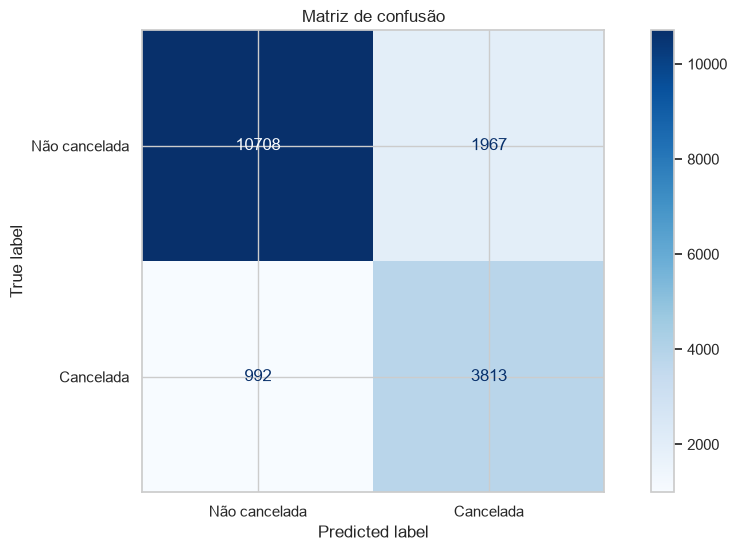

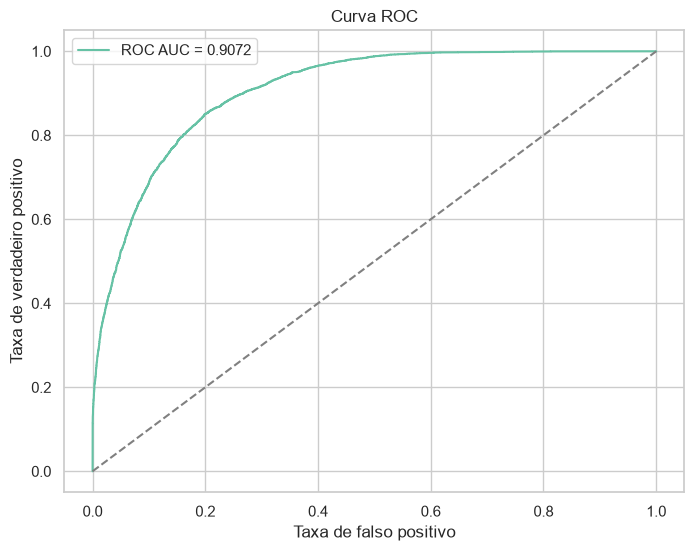

In [24]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]
y_pred_tuned = (y_proba >= best_threshold).astype(int)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)

print(f'Acurácia (limiar padrão 0.50): {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Limiar ótimo por F1: {best_threshold:.4f}')
print(f'Acurácia (limiar otimizado): {tuned_accuracy:.4f}')
print(f'F1 (limiar otimizado): {tuned_f1:.4f}')
print(f'Recall da classe cancelada (limiar otimizado): {tuned_recall:.4f}')
print('\nRelatório de classificação:')
print(classification_report(y_test, y_pred_tuned, digits=4))

cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não cancelada', 'Cancelada'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusão')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Taxa de falso positivo')
plt.ylabel('Taxa de verdadeiro positivo')
plt.title('Curva ROC')
plt.legend()
plt.show()

## 7. Conclusão

A análise exploratória mostrou que o cancelamento está fortemente associado à antecedência da reserva, ao tipo de hotel e ao tipo de depósito. Esses sinais ajudam a interpretar o comportamento das reservas e a identificar padrões úteis para tomada de decisão.

Na etapa preditiva, o modelo supervisionado conseguiu capturar com bom desempenho as reservas com maior risco de cancelamento, especialmente após o ajuste do limiar de decisão para priorizar a classe de interesse.

Resultados principais da solução: acurácia otimizada de 0.8307, F1 da classe cancelada de 0.7205, recall da classe cancelada de 0.7935 e ROC AUC de 0.9072.

**Autor:** Jonathan Euzébio Boza